# Amazon UK Product Insights – Bivariate EDA

## Lab: EDA Bivariate Analysis

In [53]:
# Import the libraries needed for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# Show the current working directory

import os

print(os.getcwd())

/Users/nsolebna/202609_Ironhack/Week 2/Day 3/Labs/lab-eda-bivariate


In [55]:
# Load the Amazon UK dataset from the previous Day 2 lab
# Reuse the existing large CSV instead of copying it

df = pd.read_csv(
    "../../../Day 2/Labs/lab-eda-univariate/amz_uk_price_prediction_dataset.csv"
)

### Dataset

The dataset used in this analysis is the Amazon UK Product Dataset provided through Kaggle.

Because the CSV file is larger than GitHub's file-size limit, it is not included in this repository. Download the dataset from the link provided in the lab README before running the notebook.

In [56]:
print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (2443651, 9)
['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']


In [57]:
## Part 1: Analyzing Best-Seller Trends Across Product Categories

### Crosstab Analysis

In [58]:
# Step 1: Create a crosstab between category and best-seller status
# Count how many True and False best-seller values appear in each category

bestseller_crosstab = pd.crosstab(
    df["category"],
    df["isBestSeller"]
)

bestseller_crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [59]:
# Step 2: Calculate the proportion of best-sellers in each category
# True behaves like 1 and False like 0
# The mean therefore gives the share of best-sellers per category
# Sort from highest to lowest proportion

bestseller_proportion = (
    df.groupby("category")["isBestSeller"]
      .mean()
      .sort_values(ascending=False)
)

bestseller_proportion

category
Grocery                             0.058135
Smart Home Security & Lighting      0.057692
Health & Personal Care              0.057686
Mobile Phone Accessories            0.042471
Power & Hand Tools                  0.035339
                                      ...   
CD, Disc & Tape Players             0.000000
General Music-Making Accessories    0.000000
Snowboard Boots                     0.000000
Boxes & Organisers                  0.000000
eBook Readers & Accessories         0.000000
Name: isBestSeller, Length: 296, dtype: float64

In [60]:
# Display the 10 categories with the highest best-seller proportion

top_10_bestseller_proportion = bestseller_proportion.head(10)

top_10_bestseller_proportion

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
Name: isBestSeller, dtype: float64

In [61]:
# Step 3: Check the number of products in each category
# This helps us interpret the best-seller proportions more carefully

category_counts = df["category"].value_counts()

category_counts.loc[top_10_bestseller_proportion.index]

category
Grocery                           9564
Smart Home Security & Lighting     104
Health & Personal Care            9569
Mobile Phone Accessories           259
Power & Hand Tools                8659
Billiard, Snooker & Pool           249
Pet Supplies                      9437
Home Brewing & Wine Making         246
Wind Instruments                   250
Mirrors                            250
Name: count, dtype: int64

In [62]:
# Combine category size and best-seller proportion

bestseller_summary = pd.DataFrame({
    "product_count": category_counts,
    "bestseller_proportion": bestseller_proportion
})

bestseller_summary.loc[top_10_bestseller_proportion.index]

,product_count,bestseller_proportion
category,,
Grocery,9564,0.058135
Smart Home Security & Lighting,104,0.057692
Health & Personal Care,9569,0.057686
Mobile Phone Accessories,259,0.042471
Power & Hand Tools,8659,0.035339
"Billiard, Snooker & Pool",249,0.032129
Pet Supplies,9437,0.030200
Home Brewing & Wine Making,246,0.028455
Wind Instruments,250,0.028000


### Interpretation of Best-Seller Prevalence

The proportion of best-sellers differs across product categories.

`Grocery` has the highest observed best-seller proportion at approximately 5.81%, followed closely by `Smart Home Security & Lighting` and `Health & Personal Care`, both at about 5.77%.

However, category size should be considered when interpreting these proportions. Some categories with high proportions contain only a few hundred products, whereas categories such as Grocery and Health & Personal Care contain more than 9,000 products.

Therefore, the results suggest that best-seller prevalence varies by category, but proportions from very small categories should be interpreted with greater caution.

In [63]:
# Step 4: Chi-square test of independence
# Test whether product category and best-seller status are statistically associated

from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(bestseller_crosstab)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 36540.20270061387
P-value: 0.0
Degrees of freedom: 295


### Interpretation of Chi-square Test

The chi-square test produced a very small p-value, effectively below 0.05.

Therefore, we reject the null hypothesis that product category and best-seller status are independent.

This indicates that best-seller status is statistically associated with product category. In other words, the proportion of best-sellers differs significantly across categories.

In [64]:
# Step 5: Calculate Cramér's V
# Measure the strength of association between category and best-seller status

n = bestseller_crosstab.to_numpy().sum()

rows, columns = bestseller_crosstab.shape

cramers_v = np.sqrt(
    chi2 / (n * min(rows - 1, columns - 1))
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.1222829439760564


### Interpretation of Cramér's V

Cramér's V is approximately 0.12.

This indicates a weak association between product category and best-seller status.

Therefore, although the chi-square test shows that the relationship is statistically significant, the strength of that relationship is relatively small. The very large dataset size makes it easier to detect statistically significant differences even when the practical association is weak.

In [65]:
# Step 6: Visualize best-seller status across the largest product categories
# Select the 10 categories with the most products
# Create a crosstab for only those categories
# Convert counts into proportions for easier comparison

top_10_categories = df["category"].value_counts().head(10).index

top_10_bestseller_crosstab = pd.crosstab(
    df.loc[df["category"].isin(top_10_categories), "category"],
    df.loc[df["category"].isin(top_10_categories), "isBestSeller"],
    normalize="index"
)

top_10_bestseller_crosstab

isBestSeller,False,True
category,,
Bath & Body,0.998272,0.001728
Beauty,0.984362,0.015638
Birthday Gifts,0.998156,0.001844
Fragrances,0.999246,0.000754
Hair Care,0.996264,0.003736
"Handmade Clothing, Shoes & Accessories",0.999272,0.000728
Make-up,0.997814,0.002186
Manicure & Pedicure Products,0.996938,0.003062
Skin Care,0.996910,0.003090


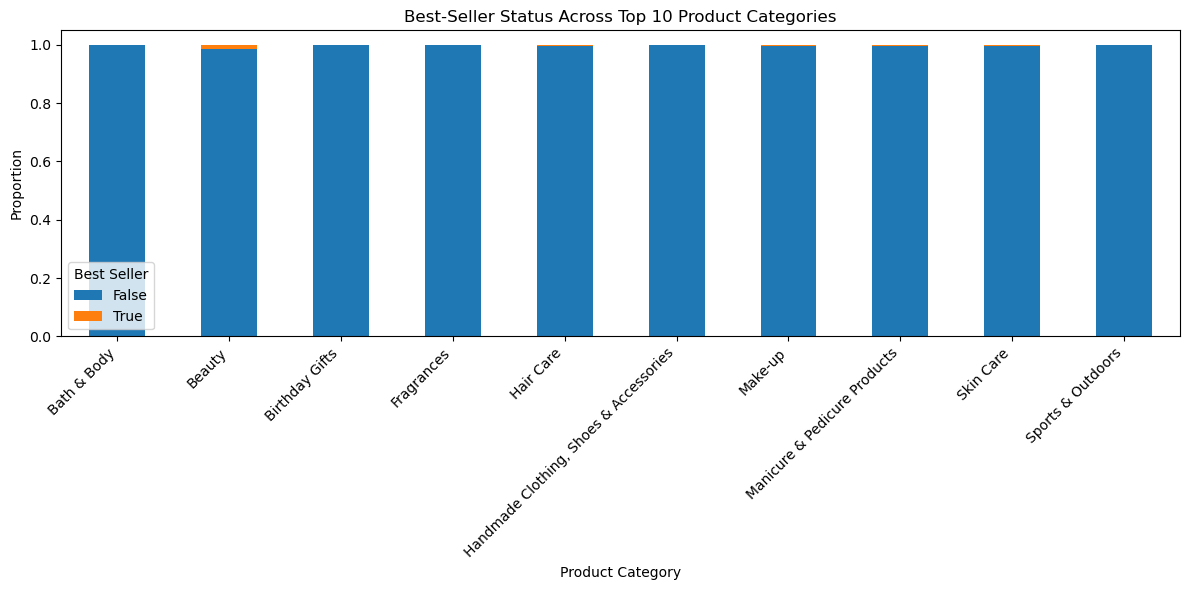

In [66]:
# Step 7: Create a stacked bar chart
# Compare best-seller and non-best-seller proportions
# across the 10 largest product categories

top_10_bestseller_crosstab.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Best-Seller Status Across Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Best Seller")

plt.tight_layout()
plt.show()

### Interpretation of Best-Seller Distribution

Across the 10 largest product categories, the vast majority of products are not best-sellers.

The proportion of best-sellers varies across categories, although it remains relatively small in all of them. Among these large categories, `Beauty` has the largest visible best-seller share, while `Sports & Outdoors` has one of the smallest.

This visual pattern is consistent with the statistical results: product category is significantly associated with best-seller status, but the overall strength of the association is weak.

In [67]:
# Part 2 - Step 1: Identify price outliers using the IQR method
# Calculate Q1 and Q3
# Calculate the IQR
# Calculate the lower and upper bounds

price_q1 = df["price"].quantile(0.25)
price_q3 = df["price"].quantile(0.75)

price_iqr = price_q3 - price_q1

price_lower_bound = price_q1 - 1.5 * price_iqr
price_upper_bound = price_q3 + 1.5 * price_iqr

print("Q1:", price_q1)
print("Q3:", price_q3)
print("IQR:", price_iqr)
print("Lower bound:", price_lower_bound)
print("Upper bound:", price_upper_bound)

Q1: 9.99
Q3: 45.99
IQR: 36.0
Lower bound: -44.01
Upper bound: 99.99000000000001


In [68]:
# Part 2 - Step 2: Remove price outliers
# Keep only products whose prices fall within the IQR boundaries
# Store the cleaned data in a new DataFrame
# Keep the original df unchanged

df_no_price_outliers = df[
    (df["price"] >= price_lower_bound) &
    (df["price"] <= price_upper_bound)
].copy()

print("Original number of rows:", len(df))
print("Rows after removing price outliers:", len(df_no_price_outliers))
print("Rows removed:", len(df) - len(df_no_price_outliers))

Original number of rows: 2443651
Rows after removing price outliers: 2115963
Rows removed: 327688


In [69]:
# Calculate the percentage of rows removed as price outliers

percentage_removed = (
    (len(df) - len(df_no_price_outliers)) / len(df)
) * 100

print("Percentage removed:", percentage_removed)

Percentage removed: 13.409770871536075


### Price Outlier Removal

Using Tukey's 1.5 × IQR rule, products priced above approximately £99.99 were classified as price outliers.

A total of 327,688 observations were removed, representing approximately 13.41% of the original dataset. The cleaned dataset contains 2,115,963 rows.

The original DataFrame was kept unchanged, and the following analyses use `df_no_price_outliers`.

In [70]:
# Part 2 - Step 3: Select the 20 most common categories
# Use the dataset after removing price outliers

top_20_categories = (
    df_no_price_outliers["category"]
    .value_counts()
    .head(20)
    .index
)

top_20_categories

Index(['Sports & Outdoors', 'Beauty', 'Bath & Body',
       'Manicure & Pedicure Products',
       'Handmade Clothing, Shoes & Accessories', 'Make-up', 'Skin Care',
       'Hair Care', 'Birthday Gifts', 'Handmade Gifts', 'Handmade Home Décor',
       'Luggage and travel gear', 'Women', 'Fragrances',
       'Handmade Kitchen & Dining', 'Handmade Artwork',
       'Handmade Home & Kitchen Products', 'Handmade Jewellery', 'Men',
       'Baby'],
      dtype='object', name='category')

In [71]:
# Keep only products belonging to the top 20 categories

top_20_data = df_no_price_outliers[
    df_no_price_outliers["category"].isin(top_20_categories)
].copy()

top_20_data.shape

(1033008, 9)

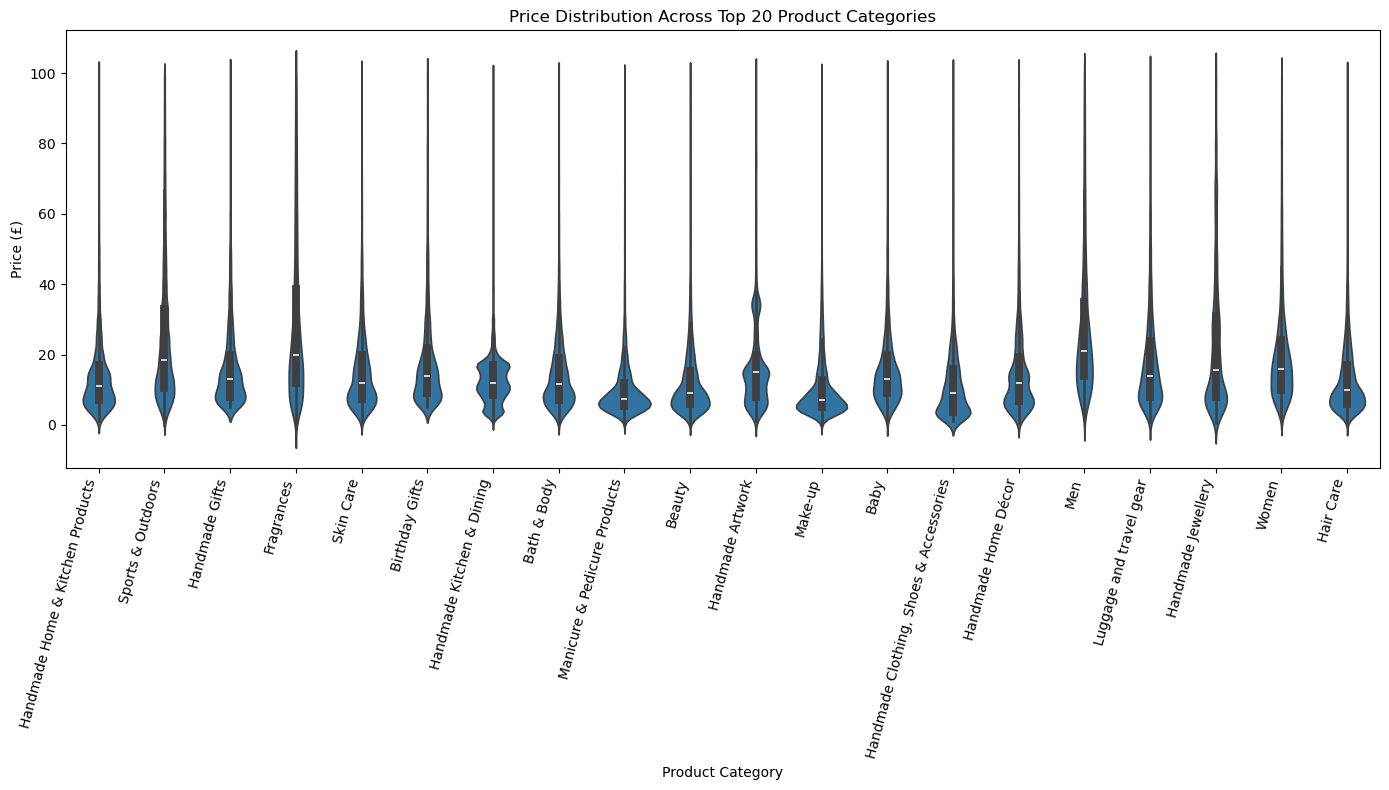

In [72]:
# Part 2 - Step 4: Visualize price distributions across the top 20 categories
# Compare how product prices are distributed within each category

plt.figure(figsize=(14, 8))

sns.violinplot(
    data=top_20_data,
    x="category",
    y="price"
)

plt.title("Price Distribution Across Top 20 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Price (£)")
plt.xticks(rotation=75, ha="right")

plt.tight_layout()
plt.show()

In [73]:
# Find the median price for every category
# Sort from highest to lowest
# Identify the category with the highest median price

category_median_price = (
    df_no_price_outliers.groupby("category")["price"]
    .median()
    .sort_values(ascending=False)
)

category_median_price.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

### Interpretation of Price Distribution

The violin plots show that product-price distributions differ across the major categories.

Most of the top 20 categories are concentrated at relatively low price levels, but the spread and shape of the distributions vary. Some categories have wider distributions, indicating greater variation in product prices, while others are more tightly concentrated.

When all categories are considered, `Desktop PCs` has the highest median product price at approximately £74.00.

In [74]:
# Part 2 - Step 5: Select the 10 most common categories
# Use the dataset after removing price outliers

top_10_price_categories = (
    df_no_price_outliers["category"]
    .value_counts()
    .head(10)
    .index
)

In [75]:
# Calculate the average price for each of the top 10 categories
# Sort from highest to lowest average price

top_10_average_price = (
    df_no_price_outliers[
        df_no_price_outliers["category"].isin(top_10_price_categories)
    ]
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

top_10_average_price

category
Sports & Outdoors                         25.172065
Birthday Gifts                            18.600195
Handmade Gifts                            17.395112
Skin Care                                 15.654722
Bath & Body                               14.678683
Hair Care                                 13.461408
Handmade Clothing, Shoes & Accessories    12.958639
Beauty                                    12.523480
Make-up                                   10.612918
Manicure & Pedicure Products              10.231825
Name: price, dtype: float64

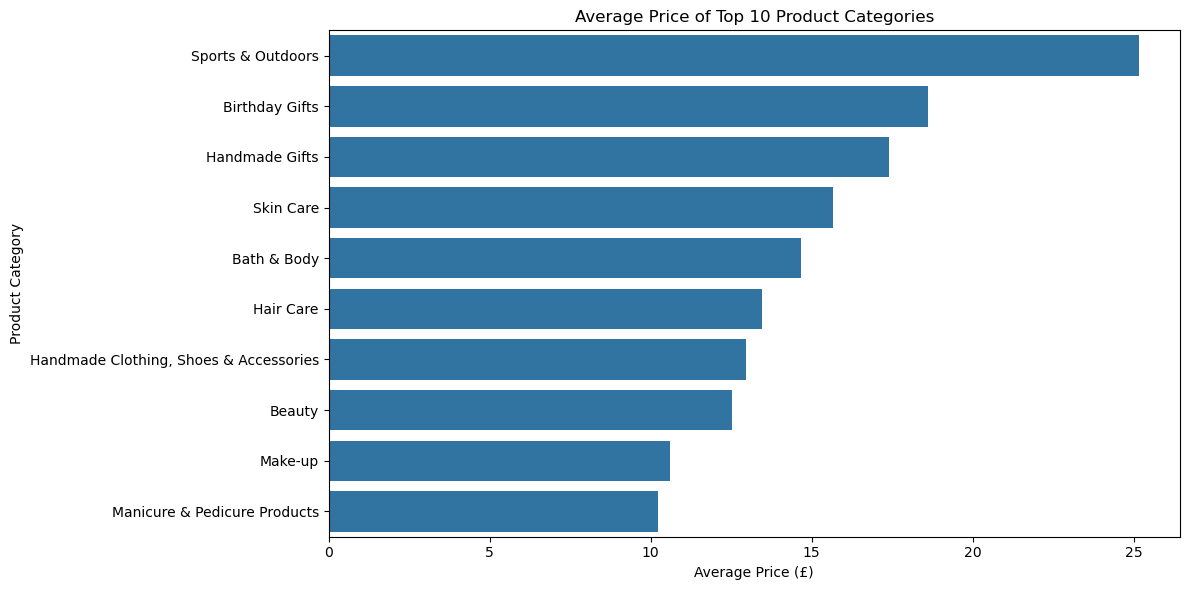

In [76]:
# Part 2 - Step 6: Visualize the average price
# for the 10 most common product categories

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_average_price.values,
    y=top_10_average_price.index
)

plt.title("Average Price of Top 10 Product Categories")
plt.xlabel("Average Price (£)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [77]:
# Calculate the average price for every category
# Sort from highest to lowest
# Identify the category with the highest average price

category_average_price = (
    df_no_price_outliers
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

category_average_price.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

In [78]:
# Part 2 - Step 7: Select the 10 most common categories
# for the ratings box plot

top_10_rating_categories = (
    df_no_price_outliers["category"]
    .value_counts()
    .head(10)
    .index
)

In [79]:
# Keep only products from the top 10 categories

top_10_rating_data = df_no_price_outliers[
    df_no_price_outliers["category"].isin(top_10_rating_categories)
].copy()

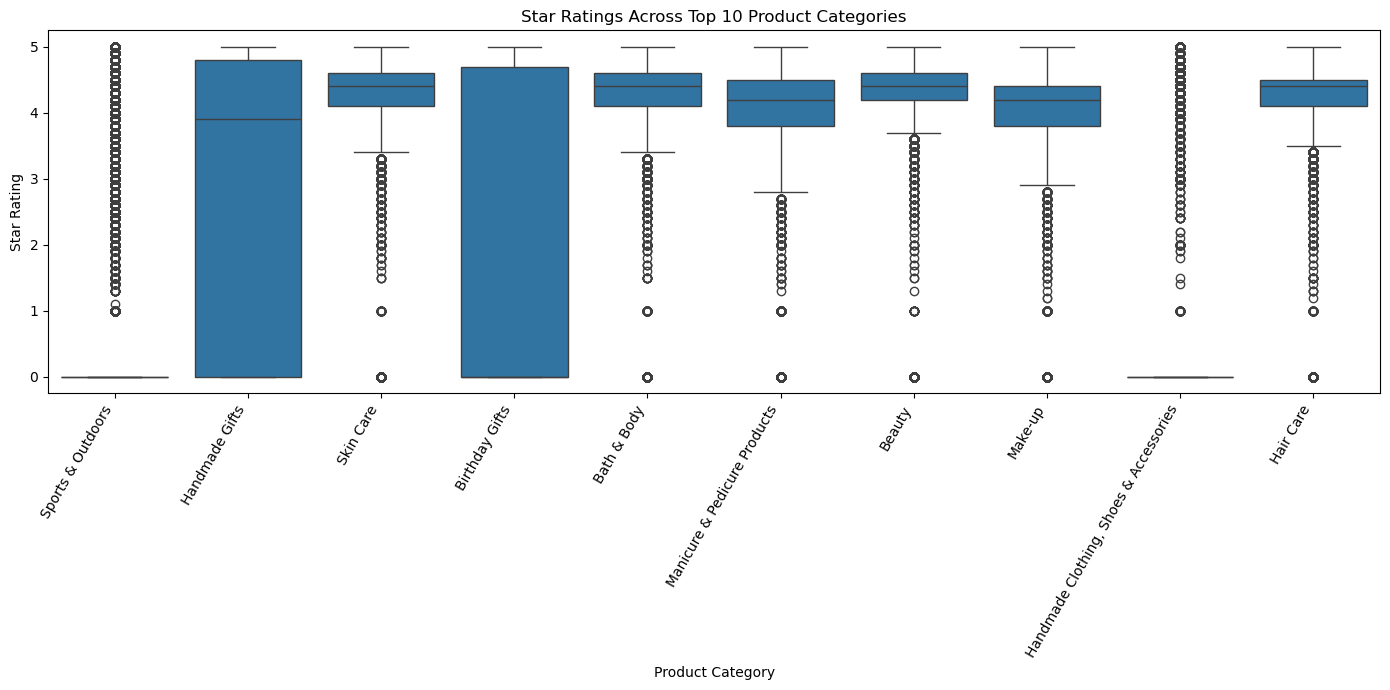

In [80]:
# Visualize star ratings across the top 10 categories

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=top_10_rating_data,
    x="category",
    y="stars"
)

plt.title("Star Ratings Across Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Star Rating")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [81]:
# Part 2 - Step 8: Remove unrated products from the ratings analysis
# Keep only products with an actual star rating above 0

rated_data = df_no_price_outliers[
    df_no_price_outliers["stars"] > 0
].copy()

In [82]:
# Find the 10 most common categories among rated products

top_10_rated_categories = (
    rated_data["category"]
    .value_counts()
    .head(10)
    .index
)

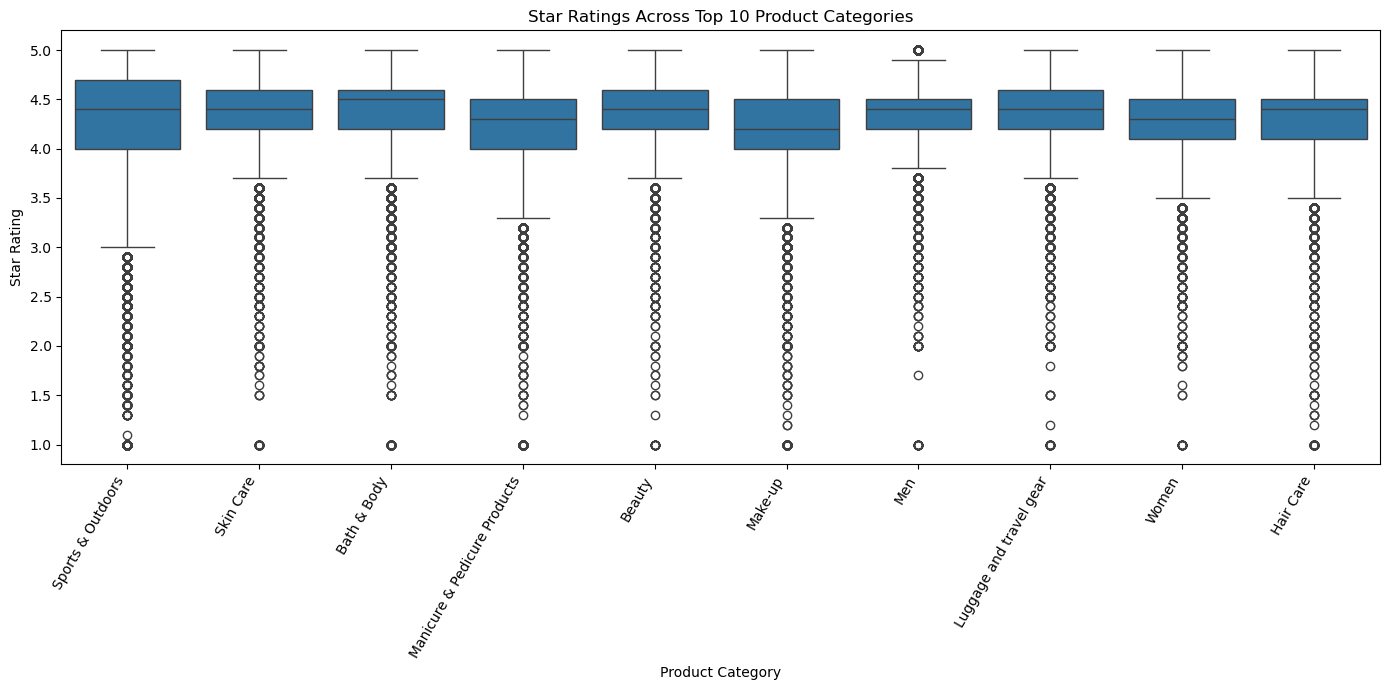

In [83]:
# Keep only rated products from the top 10 categories

top_10_rated_data = rated_data[
    rated_data["category"].isin(top_10_rated_categories)
].copy()

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=top_10_rated_data,
    x="category",
    y="stars"
)

plt.title("Star Ratings Across Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Star Rating")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [84]:
# Part 2 - Step 9: Find the median rating for every category
# Use only products with actual ratings
# Sort from highest to lowest

category_median_rating = (
    rated_data
    .groupby("category")["stars"]
    .median()
    .sort_values(ascending=False)
)

category_median_rating.head(10)


category
Made in Italy Handmade                    5.0
Handmade Baby Products                    5.0
Handmade Artwork                          5.0
Handmade Kitchen & Dining                 4.9
Handmade Clothing, Shoes & Accessories    4.9
Handmade Gifts                            4.8
Birthday Gifts                            4.8
Handmade Home Décor                       4.8
Handmade Home & Kitchen Products          4.7
Gifts for Him                             4.7
Name: stars, dtype: float64

In [85]:
# Check the number of rated products in the categories
# with the highest median ratings

rated_category_counts = rated_data["category"].value_counts()

rated_category_counts.loc[
    category_median_rating.head(10).index
]

category
Made in Italy Handmade                      303
Handmade Baby Products                     1235
Handmade Artwork                           4155
Handmade Kitchen & Dining                  2739
Handmade Clothing, Shoes & Accessories     4429
Handmade Gifts                             9871
Birthday Gifts                             7875
Handmade Home Décor                        7966
Handmade Home & Kitchen Products          10722
Gifts for Him                               273
Name: count, dtype: int64

### Interpretation of Rating Distribution

After excluding products with `stars = 0`, customer ratings are generally concentrated at the high end of the scale.

The highest median rating is 5.0 stars, shared by `Made in Italy Handmade`, `Handmade Baby Products`, and `Handmade Artwork`.

These categories contain 303, 1,235, and 4,155 rated products respectively, so the high medians are not based on single observations. However, their sample sizes are still smaller than those of the largest categories and should be interpreted in that context.

In [86]:

# Part 3 - Step 1: Measure the correlation between price and star rating
# Use only products with actual ratings

price_rating_correlation = rated_data["price"].corr(
    rated_data["stars"]
)

print("Correlation between price and star rating:", price_rating_correlation)

Correlation between price and star rating: 0.006744508067157907


### Interpretation of Price–Rating Correlation

The Pearson correlation coefficient between product price and star rating is approximately 0.007.

This value is extremely close to zero, indicating essentially no linear relationship between price and customer rating.

In practical terms, higher-priced products do not appear to systematically receive higher or lower star ratings.

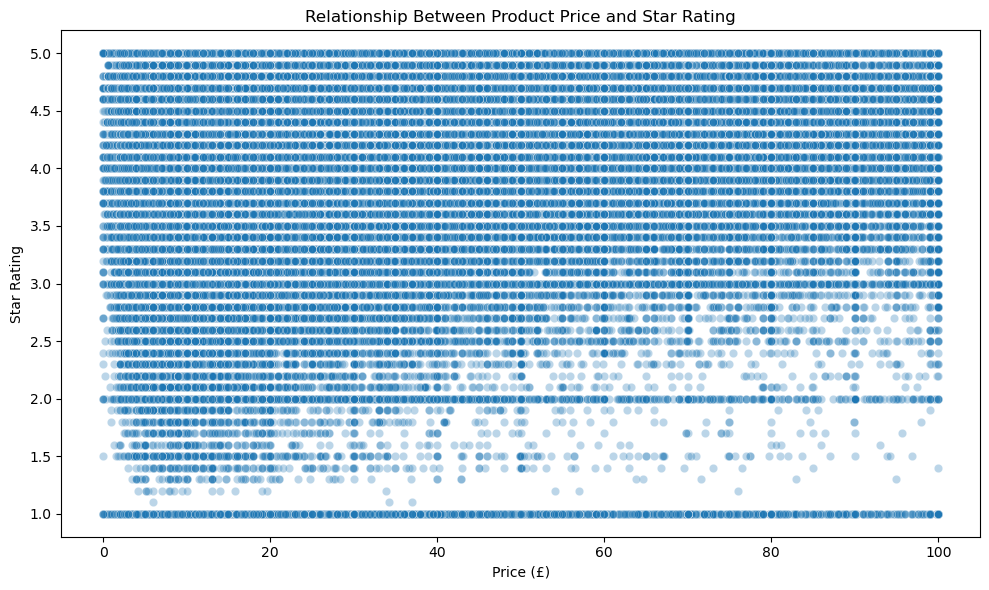

In [87]:
# Part 3 - Step 2: Visualize the relationship between price and star rating

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rated_data,
    x="price",
    y="stars",
    alpha=0.3
)

plt.title("Relationship Between Product Price and Star Rating")
plt.xlabel("Price (£)")
plt.ylabel("Star Rating")

plt.tight_layout()
plt.show()

### Interpretation of the Price–Rating Scatter Plot

The scatter plot shows no clear upward or downward relationship between product price and star rating.

Ratings are widely spread across the price range, with many products receiving ratings between 4 and 5 stars regardless of price.

This visual pattern agrees with the Pearson correlation coefficient of approximately 0.007, indicating essentially no linear relationship between product price and customer rating.

In [93]:
# Part 3 - Step 3: Calculate correlations among meaningful numerical variables
# Exclude uid because it is an identifier
# Use rated products so stars = 0 does not represent unrated products

numeric_data_rated = rated_data[
    ["stars", "reviews", "price", "boughtInLastMonth"]
]

correlation_matrix_rated = numeric_data_rated.corr()

correlation_matrix_rated

,stars,reviews,price,boughtInLastMonth
stars,1.000000,0.033487,0.006745,0.039851
reviews,0.033487,1.000000,-0.003168,0.097969
price,0.006745,-0.003168,1.000000,-0.073517
boughtInLastMonth,0.039851,0.097969,-0.073517,1.000000


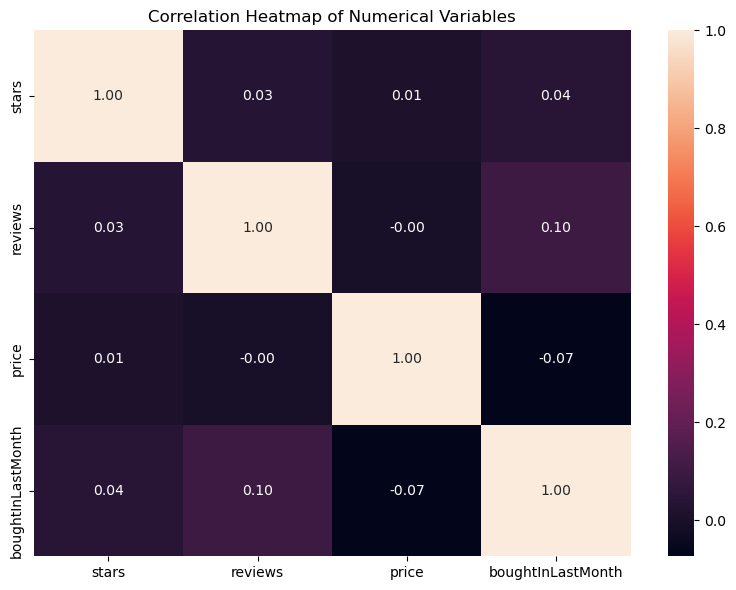

In [95]:
# Visualize the correlation matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix_rated,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

### Interpretation of the Correlation Heatmap

The correlation heatmap shows that the numerical variables generally have weak linear relationships with one another.

The strongest observed relationship is between `reviews` and `boughtInLastMonth`, with a correlation of approximately 0.10, indicating only a weak positive association.

The relationship between `price` and `stars` is approximately 0.007, which is essentially zero. Product price also shows only a weak negative correlation with `boughtInLastMonth` of about -0.07.

Overall, none of the numerical variables show a strong linear relationship with one another.

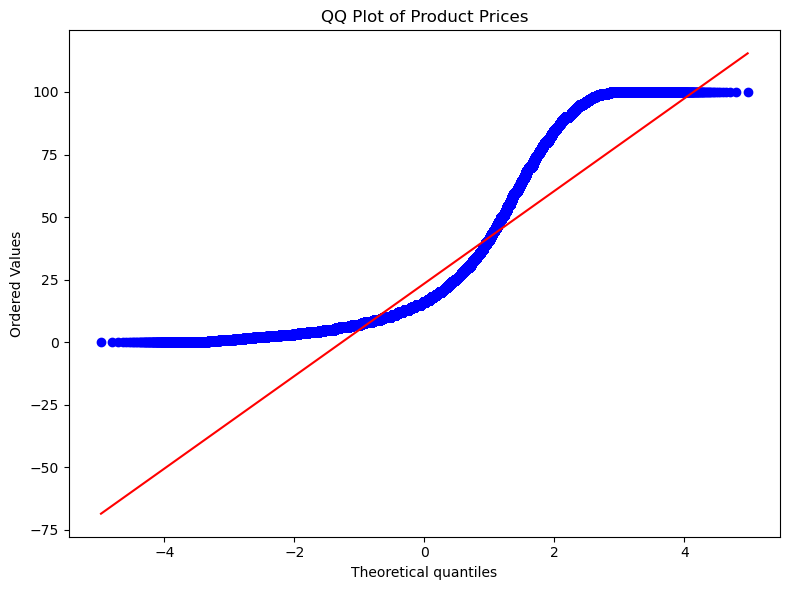

In [90]:
# Part 3 - Step 4: Check whether product prices follow a normal distribution
# Create a QQ plot using the cleaned price data

from scipy import stats

plt.figure(figsize=(8, 6))

stats.probplot(
    df_no_price_outliers["price"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Product Prices")

plt.tight_layout()
plt.show()


### Interpretation of the QQ Plot

The QQ plot shows substantial deviations from the reference line, indicating that product prices do not follow a normal distribution.

The curved pattern suggests a strongly non-normal and right-skewed price distribution, even after removing extreme price outliers using the IQR method.

Therefore, the assumption of normality is not appropriate for the product price variable.

## Business Summary

The bivariate analysis reveals several important patterns in the Amazon UK product dataset:

- Best-seller status varies significantly across product categories, although the overall association between category and best-seller status is weak.
- Product prices differ considerably across categories. Some categories, such as Motherboards and Desktop PCs, tend to have much higher typical prices than others.
- Customer ratings are generally high, with many categories having median ratings above 4 stars.
- Product price shows essentially no meaningful linear relationship with customer rating.
- The numerical variables in the dataset generally show weak correlations with one another.
- Product prices remain strongly non-normal and right-skewed even after removing extreme price outliers.

Overall, category appears to be more useful than price for explaining differences in product characteristics, while higher prices do not necessarily correspond to higher customer ratings.

## Bonus: Analysis Without Removing Price Outliers

The main analysis removed extreme price values using Tukey's 1.5 × IQR rule.  
This bonus section compares selected results using the original dataset to evaluate how strongly the price outliers influence the analysis.

# BONUS - Step 1: Compare price statistics
# Compare the original dataset with the dataset after removing price outliers

price_comparison = pd.DataFrame({
    "Original Data": [
        df["price"].mean(),
        df["price"].median(),
        df["price"].std(),
        df["price"].max()
    ],
    "Without Outliers": [
        df_no_price_outliers["price"].mean(),
        df_no_price_outliers["price"].median(),
        df_no_price_outliers["price"].std(),
        df_no_price_outliers["price"].max()
    ]
},
index=["Mean", "Median", "Standard Deviation", "Maximum"])

price_comparison

### Interpretation of Price Statistics With and Without Outliers

Removing price outliers has a substantial effect on the price distribution.

The mean price decreases from approximately £89.24 to £23.41, while the standard deviation drops from about £345.61 to £20.51. The maximum price also decreases dramatically from £100,000 to approximately £99.99.

In contrast, the median changes much less, from £19.09 to £15.99.

This demonstrates that extreme prices strongly influence the mean and standard deviation, whereas the median is much more resistant to outliers.

In [92]:
# BONUS - Step 2: Compare price-rating correlation
# Use rated products only so that stars = 0 does not represent unrated products

rated_original = df[df["stars"] > 0].copy()

correlation_with_outliers = rated_original["price"].corr(
    rated_original["stars"]
)

correlation_without_outliers = rated_data["price"].corr(
    rated_data["stars"]
)

print("Correlation with price outliers:", correlation_with_outliers)
print("Correlation without price outliers:", correlation_without_outliers)

Correlation with price outliers: -0.004911823000752921
Correlation without price outliers: 0.006744508067157907


### Interpretation of Correlation With and Without Price Outliers

The correlation between product price and star rating is approximately -0.005 when price outliers are included and approximately 0.007 after removing them.

Both values are extremely close to zero.

Therefore, removing extreme price values does not materially change the conclusion: product price has essentially no linear relationship with customer star rating.

## Bonus: Analysis Without Removing Price Outliers

The main analysis removed extreme price values using Tukey's 1.5 × IQR rule.
This bonus section compares selected results using the original dataset to evaluate how strongly the price outliers influence the analysis.

### BONUS - Step 1: Compare Price Statistics

Therefore, removing extreme price values does not materially change the conclusion: product price has essentially no meaningful linear relationship with customer star rating.